# **Análisis exploratorio de datos**

## Importar librerias

In [58]:
# Importar librerias
import pandas as pd
from datetime import datetime
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importar bases de datos

In [59]:
df_orders = pd.read_csv('data/raw/orders_data.csv')

df_stores = pd.read_csv('data/raw/stores_data.csv')

In [60]:
df_orders.head()

,created_date,APP_ORIGIN,markdown,free_shipping_flag,promedio_shipping_cost,store_id,TPN,TPV,GMV_LC,month,year
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,41200.0,20600.0,1,2024
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,13000.0,1,2024
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,405200.0,229200.0,1,2024
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,138000.0,23000.0,1,2024
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,34000.0,1,2024


In [61]:
df_stores.head()

,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


In [62]:
print(f'Columnas de df_orders: {df_orders.columns}')
print(f'Columnas de df_stores: {df_stores.columns}')

Columnas de df_orders: Index(['created_date', 'APP_ORIGIN', 'markdown', 'free_shipping_flag',
       'promedio_shipping_cost', 'store_id', 'TPN', 'TPV', 'GMV_LC', 'month',
       'year'],
      dtype='object')
Columnas de df_stores: Index(['created_date', 'status', 'segmento', 'comision_actual',
       'logistic_type', 'store_type', 'barrio', 'category', 'cooking_time',
       'tiene_otra_app', 'brand_id', 'store_id'],
      dtype='object')


In [63]:
# Renombrar columnas para practicidad

df_orders.rename(columns={'created_date': 'orders_date',
                          'APP_ORIGIN': 'app_origin',
                          'promedio_shipping_cost': 'avg_shipping_cost',
                          'free_shipping_flag': 'free_shipping',
                          'TPN': 'tpn',
                          'TPV': 'tpv',
                          'GMV_LC': 'gmv'
                          }, inplace=True)

## Data cleaning

### *df_stores*

In [64]:
df_stores.head()

,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


#### *status*

In [65]:
pd.DataFrame({'count': df_stores['status'].value_counts(dropna=False), 'percentage': (df_stores['status'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
status,,
active,9992,99.37
inactive,54,0.54
paused,9,0.09


Solo nos interesan aquellos locales activos

In [66]:
# Filtrar df_stores para quedarse solo con los registros con STATUS 'active'
df_stores = df_stores[df_stores['status'] == 'active']

if 'status' in df_stores.columns:
    df_stores.drop(columns=['status'], inplace=True)

#### *brand_id*

In [67]:
pd.DataFrame({'missing_count': df_stores.isnull().sum(), 'missing_pct': (df_stores.isnull().sum()/len(df_stores)*100).round(2)}).query("missing_count>0").sort_values('missing_count', ascending=False)

,missing_count,missing_pct
brand_id,2012,20.14
barrio,969,9.70
category,730,7.31
comision_actual,504,5.04
cooking_time,366,3.66
store_type,322,3.22
tiene_otra_app,322,3.22
segmento,1,0.01


Hay 2012 valores faltantes en la columna *brand_id*. Esto se debe a que muchos stores son locales pequeños con un unico local, en lugar de una marca grande con multiples stores/sucursales como mcdondalds por ejemplo

In [68]:
# Encontrar el valor más grande de brand_id ignorando NaN
max_brand_id = df_stores['brand_id'].dropna().max()

# Crear un contador que empieza en el siguiente entero al máximo brand_id
contador = int(max_brand_id) + 1

# Asignar un brand_id nuevo a cada registro sin brand_id
# Creamos una máscara para los registros con brand_id nulo
mask_na = df_stores['brand_id'].isna()

# Asignar valores únicos a cada registro sin brand_id
df_stores.loc[mask_na, 'brand_id'] = range(contador, contador + mask_na.sum())

# Convertir brand_id a int para evitar decimales
df_stores['brand_id'] = df_stores['brand_id'].astype(int)

#### *creation_date*

In [69]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16T22:10:44.806Z,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16T21:24:41.804Z,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16T21:09:19.795Z,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16T21:08:58.784Z,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [70]:
# Guardar la columna original
df_stores['creation_date_original'] = df_stores['created_date']

# fuerza parseo a UTC (aware) y luego removemos la info de tz
df_stores["created_date"] = pd.to_datetime(df_stores["created_date"], errors="coerce", utc=True).dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize()

In [71]:
# Ver años, meses y días únicos
print("Años únicos:", df_stores['created_date'].dt.year.unique())
print("Meses únicos:", df_stores['created_date'].dt.month.unique())
print("Días únicos:", df_stores['created_date'].dt.day.unique())

Años únicos: [2025 2024]
Meses únicos: [ 9  8  7  6  5  4  3  2  1 12 11 10]
Días únicos: [16 15  4  3  2 29 28 27 26 25 21 20 19 18 14 13 12 11  8  7  6  5  1 31
 30 24 23 22 17  9 10]


In [72]:
df_stores.drop(columns=['creation_date_original'], inplace=True)

In [73]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


#### *segmento*

In [74]:
pd.DataFrame({'count': df_stores['segmento'].value_counts(dropna=False), 'percentage': (df_stores['segmento'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
segmento,,
Microstores,7020,70.26
Top Players,1620,16.21
Picked Locals,1349,13.50
0,2,0.02
NaN,1,0.01


In [75]:
# Filas donde segmento es 0 o NaN
segmento_0_nan = df_stores[(df_stores['segmento'] == "0") | (df_stores['segmento'].isna())]

segmento_0_nan

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
5931,2025-01-17,0,36.0,3P,Brand expansion,BELGRANO,Empanadas,15 min,Sí,12808,104747
7007,2024-10-18,0,27.0,3P,New brand,PALERMO,Helado,15 min,Sí,13326,107259
9215,2024-04-20,NaN,19.5,2P,Brand expansion,BELGRANO,Sushi,NaN,Sí,12228,106165


In [76]:
# Verificar si los registros en segmento_0_nan tienen brand_id que aparecen en otros registros de df_stores
for idx, row in segmento_0_nan.iterrows():
    brand_id = row['brand_id']
    count = df_stores[df_stores['brand_id'] == brand_id].shape[0]
    print(f"brand_id {brand_id} aparece en {count} registro(s) en df_stores")

brand_id 12808 aparece en 3 registro(s) en df_stores
brand_id 13326 aparece en 87 registro(s) en df_stores
brand_id 12228 aparece en 7 registro(s) en df_stores


In [77]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[0]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
5930,2025-01-17,Picked Locals,36.0,3P,Brand expansion,ALMAGRO,Empanadas,15 min,Sí,12808,109220
5931,2025-01-17,0,36.0,3P,Brand expansion,BELGRANO,Empanadas,15 min,Sí,12808,104747
5935,2025-01-17,Picked Locals,36.0,3P,New brand,MATADEROS,Empanadas,15 min,Sí,12808,103999


In [78]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[1]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
161,2025-08-15,Top Players,27.0,3P,Brand expansion,MANANTIALES,Helado,10 min,Sí,13326,100385
549,2025-08-05,Top Players,27.0,3P,Brand expansion,JARDIN DEL SUD,Helado,10 min,Sí,13326,109149
592,2025-08-04,Top Players,27.0,3P,Brand expansion,VILLA MAIPÚ,Helado,10 min,Sí,13326,112082
595,2025-08-04,Top Players,27.0,3P,Brand expansion,VILLA MAIPÚ,Helado,10 min,Sí,13326,102893
596,2025-08-04,Top Players,27.0,3P,Brand expansion,LAS FLORES,Helado,10 min,Sí,13326,112717
597,2025-08-04,Top Players,27.0,3P,Brand expansion,RESIDENCIAL SAN CARLOS,Helado,10 min,Sí,13326,110311
764,2025-07-28,Top Players,27.0,3P,Brand expansion,ALTO ALBERDI,Helado,10 min,Sí,13326,112418
767,2025-07-28,Top Players,27.0,3P,Brand expansion,NUEVA POMPEYA,Helado,10 min,Sí,13326,101769
802,2025-07-25,Top Players,27.0,3P,Brand expansion,LOS NARANJOS,Helado,10 min,Sí,13326,113029
967,2025-07-21,Top Players,27.0,3P,Brand expansion,OBRERO,Helado,10 min,Sí,13326,112125


In [79]:
df_stores[df_stores['brand_id'] == segmento_0_nan.iloc[2]['brand_id']]

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
8799,2024-05-30,Picked Locals,19.5,2P,Brand expansion,BALVANERA,Sushi,NaN,Sí,12228,106008
8800,2024-05-30,Picked Locals,19.5,2P,Brand expansion,VILLA URQUIZA,Sushi,NaN,Sí,12228,112896
8801,2024-05-30,Picked Locals,19.5,2P,Brand expansion,CABALLITO,Sushi,NaN,Sí,12228,113534
8813,2024-05-29,Picked Locals,19.5,2P,Brand expansion,PALERMO,Sushi,NaN,Sí,12228,100217
9215,2024-04-20,NaN,19.5,2P,Brand expansion,BELGRANO,Sushi,NaN,Sí,12228,106165
9266,2024-04-16,Picked Locals,19.5,2P,Brand expansion,FLORESTA,Sushi,35 min,Sí,12228,113861
9505,2024-03-15,Microstores,NaN,2P,Multi brand,NaN,Sushi,NaN,Sí,12228,115199


Se pueden imputar esos 3 stores al no ser muchos

In [80]:
df_stores = df_stores[df_stores['segmento'].notna() & (df_stores['segmento'] != "0")]

#### *logistic_type*

In [81]:
df_stores.head()

,created_date,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [82]:
df_stores['logistic_type'].unique()

array(['3P', '2P'], dtype=object)

In [83]:
df_stores.rename(columns={'logistic_type': 'in-house_delivery'}, inplace=True)
df_stores['in-house_delivery'] = df_stores['in-house_delivery'].replace({'3P': '0', '2P': '1'}).astype(int)

#### *store_type*

In [84]:
df_stores.head()

,created_date,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16,Microstores,42.0,0,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060,107643
1,2025-09-16,Microstores,42.0,0,New brand,NUEVA CORDOBA,China,25 min,Sí,13049,100827
2,2025-09-16,Microstores,42.0,0,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689,107223
3,2025-09-16,Microstores,42.0,0,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955,102438
4,2025-09-16,Microstores,42.0,0,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502,112782


In [85]:
pd.DataFrame({'count': df_stores['store_type'].value_counts(dropna=False), 'percentage': (df_stores['store_type'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
store_type,,
New brand,6407,64.14
Brand expansion,2839,28.42
Multi brand,421,4.21
NaN,322,3.22


#### *barrio* y asignamos ciudad

In [86]:
pd.set_option('display.max_rows', None)

In [87]:
pd.DataFrame({'count': df_stores['barrio'].value_counts(dropna=False), 'percentage': (df_stores['barrio'].value_counts(normalize=True, dropna=False) * 100).round(2)}).sort_index()

,count,percentage
barrio,,
ACASSUSO,29,0.29
AGRONOMÍA,10,0.10
ALBERDI,49,0.49
ALBERTO OLMEDO,2,0.02
ALMAGRO,276,2.76
ALTA CORDOBA,49,0.49
ALTA CÓRDOBA,13,0.13
ALTAMIRA,1,0.01
ALTO ALBERDI,27,0.27


In [88]:
# Convertir a minúsculas y eliminar tildes en la columna 'barrio'
def limpiar_barrio(barrio):
    if pd.isnull(barrio):
        return barrio
    barrio = barrio.lower()
    barrio = unicodedata.normalize('NFKD', barrio).encode('ASCII', 'ignore').decode('utf-8')
    return barrio

df_stores['barrio'] = df_stores['barrio'].apply(limpiar_barrio)

In [89]:
# Función para asignar la ciudad basada en el barrio
def assign_city(barrio):
    barrios_caba = [
        'agronomia', 'almagro', 'balvanera', 'barracas', 'belgrano', 'boedo', 'caballito', 'chacarita',
        'coghlan', 'colegiales', 'constitucion', 'flores', 'floresta', 'la boca', 'la paternal', 'liniers',
        'mataderos', 'monserrat', 'monte castro', 'nueva pompeya', 'nunez', 'palermo', 'parque avellaneda',
        'parque chacabuco', 'parque chas', 'parque patricios', 'puerto madero', 'recoleta', 'retiro', 'saavedra',
        'san cristobal', 'san nicolas', 'san telmo', 'velez sarsfield', 'versalles', 'villa crespo',
        'villa del parque', 'villa devoto', 'villa general mitre', 'villa lugano', 'villa luro',
        'villa ortuzar', 'villa pueyrredon', 'villa real', 'villa riachuelo', 'villa santa rita',
        'villa soldati', 'villa urquiza'
    ]

    barrios_gba = [
    'acassuso', 'avellaneda', 'beccar', 'boulogne sur mer', 'carapachay', 'ciudadela', 'crucesita', 
    'florida', 'florida oeste', 'gerli', 'haedo', 'la lucila', 'lomas del mirador', 
    'martinez', 'moron', 'munro', 'olivos', 'pineyro', 'ramos mejia', 'san isidro', 'san justo', 
    'san martin centro', 'vicente lopez', 'villa adelina', 'villa ballester', 'villa bonich', 
    'villa luzuriaga', 'villa lynch', 'villa maipu', 'villa martelli', 'villa san andres', 
    'villa sarmiento'
]
    
    barrios_cordoba = [
        'alberdi', 'alta cordoba', 'altamira', 'alto alberdi', 'alto general paz', 'altos de velez sarsfield',
        'ameghino norte', 'ampliacion jardin espinosa', 'ampliacion kennedy', 'ampliacion pueyrredon', 'avenida',
        'bialet masse', 'california', 'carola lorenzini', 'caseros', 'centro', 'cerro de las rosas', 'cofico', 'colon',
        'crisol norte', 'crisol sud', 'ducasse', 'el trebol', 'empalme', 'ferrer', 'general bustos', 'general paz',
        'general pueyrredon', 'guemes', 'independencia', 'ipona', 'jardin', 'jardin del sud', 'jardin espinosa',
        'jardin hipodromo', 'jardines del jockey', 'jockey club', 'jose ignacio diaz cuarta seccion', 'juan xxiii',
        'juniors', 'kennedy', 'lamadrid', 'las flores', 'los naranjos', 'los olmos', 'los platanos', 'maipu primera seccion',
        'manantiales', 'mariano balcarce', 'nueva cordoba', 'obrero', 'observatorio', 'panamericano', 'parque atlantica',
        'parque capital', 'parque horizonte', 'parque san vicente', 'parque sarmiento', 'paso de los andes', 'poeta lugones',
        'providencia', 'puente blanco', 'quebrada de las rosas', 'quinta santa ana', 'residencial olivos', 'residencial san carlos',
        'rivadavia', 'rosedal', 'san cayetano', 'san daniel', 'san fernando', 'san martin', 'san rafael', 'san vicente', 'smata',
        'teniente benjamin matienzo', 'villa revol', 'villa san carlos', 'villa silvano funes', 'yapeyu'
    ]

    barrios_rosario = [
        'centro', 'las malvinas', 'lisandro de la torre', 'luis agote'
    ]

    if barrio in barrios_caba:
        return 'CABA'
    elif barrio in barrios_gba:
        return 'GBA'
    elif barrio in barrios_cordoba:
        return 'Córdoba'
    elif barrio in barrios_rosario:
        return 'Rosario'
    elif 'la plata' in barrio:
        return 'La Plata'
    else:
        return None  # quedar como None

df_stores['barrio'] = df_stores['barrio'].astype(str)
df_stores['ciudad'] = df_stores['barrio'].apply(assign_city)

#### *cooking_time*

In [90]:
pd.DataFrame({'count': df_stores['cooking_time'].value_counts(dropna=False), 'percentage': (df_stores['cooking_time'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
cooking_time,,
20 min,3893,38.97
15 min,1971,19.73
10 min,1524,15.26
25 min,677,6.78
30 min,645,6.46
5 min,527,5.28
NaN,365,3.65
35 min,187,1.87
40 min,98,0.98


In [91]:
# Eliminar "min" y convertir la columna cooking_time a int
df_stores['cooking_time'] = df_stores['cooking_time'].str.replace('min', '', regex=False).str.strip()
df_stores['cooking_time'] = pd.to_numeric(df_stores['cooking_time'], errors='coerce').astype('Int64')

#### *tiene_otra_app*

In [92]:
pd.DataFrame({'count': df_stores['tiene_otra_app'].value_counts(dropna=False), 'percentage': (df_stores['tiene_otra_app'].value_counts(normalize=True, dropna=False) * 100).round(2)})

,count,percentage
tiene_otra_app,,
Sí,6335,63.42
No,3332,33.36
NaN,322,3.22


In [93]:
df_stores['tiene_otra_app'] = df_stores['tiene_otra_app'].replace({'Sí': '1', 'No': '0'}).astype('Int64')

### *df_orders*

In [94]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867259 entries, 0 to 1867258
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   orders_date        object 
 1   app_origin         object 
 2   markdown           float64
 3   free_shipping      int64  
 4   avg_shipping_cost  float64
 5   store_id           float64
 6   tpn                int64  
 7   tpv                float64
 8   gmv                float64
 9   month              int64  
 10  year               int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 156.7+ MB


##### *orders_date*

In [95]:
# Guardar la columna original
df_orders['orders_date_original'] = df_orders['orders_date']

# Convertir orders_date a datetime
df_orders['orders_date'] = pd.to_datetime(df_orders['orders_date'], errors='coerce')

In [96]:
# Ver años, meses y días únicos
print("Años únicos:", df_orders['orders_date'].dt.year.unique())
print("Meses únicos:", df_orders['orders_date'].dt.month.unique())
print("Días únicos:", df_orders['orders_date'].dt.day.unique())

Años únicos: [2024 2025]
Meses únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Días únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]


In [97]:
df_orders.drop(columns=['orders_date_original'], inplace=True)

##### *app_origin*

In [98]:
df_orders['app_origin'].unique()

array(['MP_IOS_WALLET', 'MP_ANDROID_WALLET', 'MELI_ANDROID', 'MELI_IOS',
       'OTHER'], dtype=object)

In [99]:
# Asumiendo df es tu DataFrame y 'app_origin' contiene valores como:
# ['MP_IOS_WALLET','MP_ANDROID_WALLET','MELI_ANDROID','MELI_IOS','OTHER']

# 1) si_ios = 1 si contiene 'IOS' (ej. MELI_IOS, MP_IOS_WALLET), 0 en caso contrario
df_orders['si_ios'] = df_orders['app_origin'].str.contains('IOS', case=False, na=False).astype(int)

# 2) si_meli = 1 si contiene 'MELI' (ej. MELI_ANDROID, MELI_IOS), 0 si es MP_* u OTHER
df_orders['si_meli'] = df_orders['app_origin'].str.contains('MELI', case=False, na=False).astype(int)

# 3) si_other = 1 si contiene 'OTHER', 0 si es MP_* o MELI_*
df_orders['si_other'] = df_orders['app_origin'].str.contains('OTHER', case=False, na=False).astype(int)

##### *tpv*

In [100]:
df_orders.drop(columns=['tpv'], inplace=True)

## EDA

In [101]:
df_stores.head(5)

,created_date,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id,ciudad
0,2025-09-16,Microstores,42.0,0,New brand,boulogne sur mer,Sándwiches,20,0,11060,107643,GBA
1,2025-09-16,Microstores,42.0,0,New brand,nueva cordoba,China,25,1,13049,100827,Córdoba
2,2025-09-16,Microstores,42.0,0,New brand,ramos mejia,Empanadas,10,0,11689,107223,GBA
3,2025-09-16,Microstores,42.0,0,New brand,la plata,Desayunos y meriendas,30,0,11955,102438,La Plata
4,2025-09-16,Microstores,42.0,0,New brand,monte castro,Sándwiches,5,0,14502,112782,CABA


In [102]:
df_orders.head(5)

,orders_date,app_origin,markdown,free_shipping,avg_shipping_cost,store_id,tpn,gmv,month,year,si_ios,si_meli,si_other
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,20600.0,1,2024,1,0,0
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,1,2024,0,0,0
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,229200.0,1,2024,0,0,0
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,23000.0,1,2024,1,0,0
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,1,2024,1,0,0


#### Armado de *weekly_master* y *monthly_master*, y features relacionadas con el churn
- Base maestra con datos históricos de ordenes por mes por store, con features estáticas de la store y features de churn mensuales
- Base maestra con datos históricos de ordenes por semana por store, con features estáticas de la store y features de churn mensuales
- Definición del churn
- Features moviles temporales del churn 

In [103]:
df_orders_local = df_orders.copy()

# normalizar fecha
if 'orders_date' in df_orders_local.columns:
    df_orders_local['orders_date'] = pd.to_datetime(df_orders_local['orders_date'])
elif {'year','month'}.issubset(df_orders_local.columns):
    df_orders_local['orders_date'] = pd.to_datetime(
        df_orders_local['year'].astype(int).astype(str) + '-' +
        df_orders_local['month'].astype(int).astype(str) + '-01'
    )
else:
    raise ValueError("Añade orders_date o year+month en df_orders")

In [104]:
# --- 0) asegurar created_date en df_stores ---
df_stores_local = df_stores.copy()
df_stores_local['created_date'] = pd.to_datetime(df_stores_local.get('created_date'), errors='coerce')

##### Armado de *monthly_master*

In [105]:
# --- Monthly aggregation (store × period_month) ---
df_orders_local['period_month'] = df_orders_local['orders_date'].dt.to_period('M')

# construir dict de NamedAgg dinámicamente (para evitar errores si alguna columna falta)
agg_args = {
    'tpn': pd.NamedAgg(column='tpn', aggfunc='sum'),
    'gmv': pd.NamedAgg(column='gmv', aggfunc='sum') if 'gmv' in df_orders_local.columns else pd.NamedAgg(column='tpn', aggfunc='sum'),
    'days_with_orders': pd.NamedAgg(column='orders_date', aggfunc=lambda s: s.dt.date.nunique()),
    'markdown_mean': pd.NamedAgg(column='markdown', aggfunc='mean'),
    'avg_shipping_cost': pd.NamedAgg(column='avg_shipping_cost', aggfunc='mean'),
    
}

# flags de canal / marketplace / shipping
for col in ['si_ios','si_meli','si_other','free_shipping']:
    if col in df_orders_local.columns:
        agg_args[f'{col}_prop'] = pd.NamedAgg(column=col, aggfunc=lambda s: s.eq(1).mean())

# ejecutar agregación
orders_monthly = (
    df_orders_local
    .groupby(['store_id','period_month'], observed=True)
    .agg(**agg_args)
    .reset_index()
)

In [106]:
df_orders_local['orders_date'].min(), df_orders_local['orders_date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-09-17 00:00:00'))

In [107]:
# --- 1) determinar último periodo global observado en orders_monthly ---
# orders_monthly['period_month'] debe ser Period[M]
if orders_monthly.empty:
    last_period = pd.Period(pd.Timestamp.now(), freq='M')
else:
    last_period = orders_monthly['period_month'].max()
    if pd.isna(last_period):
        last_period = pd.Period(pd.Timestamp.now(), freq='M')

# --- 2) Grid monthly: desde created_date (primer periodo) hasta last_period ---
parts = []
stores_iter = df_stores_local[['store_id','created_date']].drop_duplicates('store_id')

for sid, created in stores_iter.itertuples(index=False):
    # Si hay created_date, usamos ese mes como start
    if pd.notna(created):
        start = pd.Period(created, freq='M')
    else:
        # fallback: si no hay created_date, intentamos empezar en el primer mes con pedidos
        first_order_series = orders_monthly.loc[orders_monthly['store_id']==sid, 'period_month']
        if not first_order_series.empty:
            start = first_order_series.min()
        else:
            # ni created_date ni pedidos: no podemos construir historial => saltamos
            continue

    # Si el start es posterior al last_period (ej store creada después del último mes con pedidos),
    # no generamos periodos (podés cambiar esto si querés incluir el mes de creación aunque no haya pedidos)
    if start > last_period:
        # opcional: si querés incluir el mes de creación aunque esté después de last_period,
        # reemplazá `continue` por `idx = pd.period_range(start, start, freq='M')`
        continue

    # rango de meses desde start hasta last_period (ambos incluidos)
    idx = pd.period_range(start, last_period, freq='M')
    tmp = pd.DataFrame({'store_id': sid, 'period_month': idx})
    parts.append(tmp)

# concatenar grid
if not parts:
    raise ValueError("No se generaron periodos: revisá created_date y orders_monthly.")

grid_monthly = pd.concat(parts, ignore_index=True).sort_values(['store_id','period_month']).reset_index(drop=True)

# --- 3) left join con orders_monthly (trae NaN cuando no hubo pedidos) ---
monthly_full = grid_monthly.merge(orders_monthly, on=['store_id','period_month'], how='left')

# --- 4) rellenar NaNs en tpn/tpv/gmv/days_with_orders de forma segura ---
monthly_full['tpn'] = monthly_full['tpn'].fillna(0).astype(float)
monthly_full['gmv'] = monthly_full['gmv'].fillna(0).astype(float)
monthly_full['days_with_orders'] = monthly_full['days_with_orders'].fillna(0).astype(int)

In [108]:
# --- 6) (opcional) revisar resultado rápido ---
print("last_period:", last_period)
print("monthly_full shape:", monthly_full.shape)
monthly_full.head(10)

last_period: 2025-09
monthly_full shape: (87111, 11)


,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop
0,100000,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,100000,2024-11,10.0,99900.0,4,0.192647,1122.625000,0.250000,0.000000,0.0,0.500000
2,100000,2024-12,100.0,1494618.0,23,0.213178,1175.461111,0.444444,0.000000,0.0,0.777778
3,100000,2025-01,78.0,1165196.0,20,0.395979,1168.689600,0.240000,0.120000,0.0,0.920000
4,100000,2025-02,48.0,808800.0,15,0.400081,1171.896667,0.166667,0.111111,0.0,1.000000
5,100000,2025-03,22.0,307838.0,9,0.355330,1141.647778,0.000000,0.000000,0.0,0.888889
6,100000,2025-04,116.0,1665194.0,27,0.474851,1220.042195,0.243902,0.146341,0.0,1.000000
7,100000,2025-05,10.0,121998.0,4,0.000000,1197.730000,0.250000,0.250000,0.0,0.750000
8,100000,2025-06,12.0,201952.0,6,0.080861,1172.906667,0.333333,0.333333,0.0,1.000000
9,100000,2025-07,40.0,533694.0,12,0.342163,1154.513333,0.266667,0.266667,0.0,0.866667


Definimos que una store este en churn a partir de TPN = 0

- churn (mes actual) -> df_churn_full['churn']
- churn_2m_consec -> lleva al menos 2 meses consecutivos
- churn_3m_consec -> lleva al menos 3 meses consecutivos
- churn_streak -> meses acumulados en churn

- churn unique -> si en ese mes cayó en churn y en los previos no lo estaba

In [109]:
# calcular churn = tpn == 0
monthly_full['churn'] = (monthly_full['tpn'] == 0).astype(int)

# rachas por store (igual que hicimos antes)
def consecutive_ones(s):
    groups = (s != s.shift()).cumsum()
    streak = s.groupby(groups).cumcount() + 1
    return (streak * s).astype(int)

monthly_full['churn_streak'] = monthly_full.groupby('store_id')['churn'].apply(consecutive_ones).reset_index(level=0, drop=True)
monthly_full['churn_2m_consec'] = (monthly_full['churn_streak'] >= 2).astype(int)
monthly_full['churn_3m_consec'] = (monthly_full['churn_streak'] >= 3).astype(int)
monthly_full['churn_unique'] = ((monthly_full['churn'] == 1) & (monthly_full['churn_streak'] == 1)).astype(int)

In [110]:
# Nueva etiqueta de stage: 'Retained', 'New', 'Reactivated', 'Churn > 3M', 'Churn', 'Churn < 3M'
    # 'Retained': si tpn > 0 y churn_streak == 0
    # 'New': si es el primer mes con tpn > 0 (y no es el primer mes del store)
    # 'Reactivated': si tpn > 0 y churn_streak > 0
    # 'Churn > 3M': si churn_streak >= 3
    # 'Churn': si tpn == 0
    # 'Churn < 3M': si 0 < churn_streak < 3
    
def determine_stage(row):
    if row['tpn'] > 0 and row['churn_streak'] == 0:
        return 'Retained'
    elif row['tpn'] > 0 and row['churn_streak'] > 0:
        return 'Reactivated'
    elif row['tpn'] == 0 and row['churn_streak'] >= 3:
        return 'Churn > 3M'
    elif row['tpn'] == 0 and row['churn_streak'] > 0:
        return 'Churn < 3M'
    elif row['tpn'] == 0 and row['churn_streak'] == 0:
        return 'Churn'
    elif row['tpn'] > 0 and row['churn_streak'] == 1:
        # Verificar si es el primer mes del store
        store_periods = monthly_full[monthly_full['store_id'] == row['store_id']]
        if not store_periods.empty and store_periods.iloc[0]['period_month'] == row['period_month']:
            return 'Retained'  # Primer mes del store con tpn > 0
        else:
            return 'New'  # No es el primer mes del store
    else:
        return 'Unknown'  # Caso por defecto (no debería ocurrir)

monthly_full['stage'] = monthly_full.apply(determine_stage, axis=1)

In [111]:
monthly_full[monthly_full['store_id'] == 100006].sort_values(['store_id', 'period_month'])

,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop,churn,churn_streak,churn_2m_consec,churn_3m_consec,churn_unique,stage
17,100006,2024-07,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,1,Churn < 3M
18,100006,2024-08,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,0,0,Churn < 3M
19,100006,2024-09,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,1,0,Churn > 3M
20,100006,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,4,1,1,0,Churn > 3M
21,100006,2024-11,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,1,0,Churn > 3M
22,100006,2024-12,6.0,145000.0,3,0.0,1112.860000,0.000000,0.0,0.0,1.0,0,0,0,0,0,Retained
23,100006,2025-01,10.0,128600.0,5,0.0,1160.570000,0.200000,0.2,0.0,1.0,0,0,0,0,0,Retained
24,100006,2025-02,10.0,184700.0,5,0.0,1127.328000,0.000000,0.0,0.0,1.0,0,0,0,0,0,Retained
25,100006,2025-03,2.0,30600.0,1,0.0,1076.870000,0.000000,0.0,0.0,1.0,0,0,0,0,0,Retained
26,100006,2025-04,2.0,54300.0,1,0.0,1135.470000,0.000000,0.0,0.0,1.0,0,0,0,0,0,Retained


Ahora unimos las features las features estáticas de las stores a monthly_master

In [112]:
# Unimos las features de df_stores a monthly_full
monthly_full = monthly_full.merge(df_stores, on='store_id', how='left')

In [113]:
monthly_full[monthly_full['store_id'] == 100006].sort_values(['store_id', 'period_month'])

,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,...,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad
17,100006,2024-07,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
18,100006,2024-08,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
19,100006,2024-09,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
20,100006,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
21,100006,2024-11,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
22,100006,2024-12,6.0,145000.0,3,0.0,1112.860000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
23,100006,2025-01,10.0,128600.0,5,0.0,1160.570000,0.200000,0.2,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
24,100006,2025-02,10.0,184700.0,5,0.0,1127.328000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
25,100006,2025-03,2.0,30600.0,1,0.0,1076.870000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
26,100006,2025-04,2.0,54300.0,1,0.0,1135.470000,0.000000,0.0,0.0,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA


##### Armado de *weekly_master*

In [118]:
# --- Weekly aggregation (store × week_start) ---
# definimos week_start como lunes (Puedes elegir domingo si preferís)
df_orders_local['week_start'] = (df_orders_local['orders_date'] - 
                                 pd.to_timedelta(df_orders_local['orders_date'].dt.weekday, unit='D')).dt.normalize()

# Construir dict de agregaciones dinámico
agg_args = {
    'tpn_week': pd.NamedAgg(column='tpn', aggfunc='sum'),
    'gmv_week': pd.NamedAgg(column='gmv', aggfunc='sum') if 'gmv' in df_orders_local.columns else pd.NamedAgg(column='tpn', aggfunc='sum'),
    'markdown_mean_week': pd.NamedAgg(column='markdown', aggfunc='mean'),
    'avg_shipping_cost_week': pd.NamedAgg(column='avg_shipping_cost', aggfunc='mean')
}

# flags por canal/marketplace/shipping
for col in ['si_ios','si_meli','si_other','free_shipping']:
    if col in df_orders_local.columns:
        agg_args[f'{col}_prop_week'] = pd.NamedAgg(column=col, aggfunc=lambda s: s.eq(1).mean())
        
# Ejecutar agregación weekly
orders_weekly = (
    df_orders_local
    .groupby(['store_id','week_start'], observed=True)
    .agg(**agg_args)
    .reset_index()
)

In [119]:
# --- 1) determinar último week_start global observado en orders_weekly ---
last_week = orders_weekly['week_start'].max()

# Helper para obtener week_start (lunes) de una fecha
def to_week_start(ts):
    ts = pd.to_datetime(ts)
    # ts.weekday() devuelve 0..6 (lunes=0)
    return (ts - pd.Timedelta(days=int(ts.weekday()))).normalize()

# --- 2) Grid weekly: desde week_start( created_date ) hasta last_week ---
parts = []
stores_iter = df_stores_local[['store_id','created_date']].drop_duplicates('store_id')

for sid, created in stores_iter.itertuples(index=False):
    # Si hay created_date, usamos la semana del created_date como start_week
    if pd.notna(created):
        start_week = to_week_start(created)
    else:
        # fallback: si no hay created_date, intentar el primer week_start con pedidos para esa tienda
        first_order_series = orders_weekly.loc[orders_weekly['store_id']==sid, 'week_start']
        if not first_order_series.empty:
            start_week = first_order_series.min()
        else:
            # ni created_date ni pedidos -> no podemos construir historial => saltamos
            continue

    # Si start_week es posterior a last_week, por defecto no generamos semanas (skip).
    if start_week > last_week:
        # Si preferís incluir al menos la semana de creación, sustituí la siguiente línea por:
        # idx = pd.date_range(start=start_week, end=start_week, freq='W-MON')
        continue

    # construir rango semanal de Mondays desde start_week hasta last_week (incluye ambos)
    # usamos freq='W-MON' para obtener lunes
    idx = pd.date_range(start=start_week, end=last_week, freq='W-MON')
    if len(idx) == 0:
        continue
    tmp = pd.DataFrame({'store_id': sid, 'week_start': idx})
    parts.append(tmp)

if not parts:
    raise ValueError("No se generaron semanas: revisá created_date y orders_weekly.")

grid_weekly = pd.concat(parts, ignore_index=True).sort_values(['store_id','week_start']).reset_index(drop=True)

# --- 3) asignar period_month (útil para merge con churn mensual) ---
grid_weekly['period_month'] = grid_weekly['week_start'].dt.to_period('M')

# --- 4) left join con orders_weekly (trae NaN cuando no hubo pedidos esa semana) ---
weekly_full = grid_weekly.merge(orders_weekly, on=['store_id','week_start'], how='left')

# --- 5) rellenar NaNs en tpn_week/gmv_week/orders_count de forma segura ---
weekly_full['tpn_week'] = weekly_full['tpn_week'].fillna(0).astype(float)
weekly_full['gmv_week'] = weekly_full['gmv_week'].fillna(0).astype(float)

In [120]:
# --- 7) sanity checks rápidos ---
print("last_week:", last_week)
print("grid_weekly shape:", grid_weekly.shape)
print("weekly_full shape:", weekly_full.shape)
weekly_full.head(10)

last_week: 2025-09-15 00:00:00
grid_weekly shape: (348094, 3)
weekly_full shape: (348094, 11)


,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,free_shipping_prop_week
0,100000,2024-10-21,2024-10,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,100000,2024-10-28,2024-10,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,100000,2024-11-04,2024-11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,100000,2024-11-11,2024-11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100000,2024-11-18,2024-11,2.0,22600.0,0.000000,1065.110000,0.000000,0.0,0.0,1.000000
5,100000,2024-11-25,2024-11,8.0,77300.0,0.256863,1141.796667,0.333333,0.0,0.0,0.333333
6,100000,2024-12-02,2024-12,16.0,213094.0,0.090300,1173.538333,0.500000,0.0,0.0,0.666667
7,100000,2024-12-09,2024-12,24.0,330634.0,0.136266,1169.931667,0.166667,0.0,0.0,0.666667
8,100000,2024-12-16,2024-12,24.0,420796.0,0.201322,1186.616667,0.666667,0.0,0.0,0.833333
9,100000,2024-12-23,2024-12,26.0,383494.0,0.323641,1166.474286,0.428571,0.0,0.0,0.857143


Definimos que una store este en churn a partir de TPN = 0

- churn (mes actual) -> df_churn_full['churn']
- churn_2m_consec -> lleva al menos 2 meses consecutivos
- churn_3m_consec -> lleva al menos 3 meses consecutivos
- churn_streak -> meses acumulados en churn

- churn unique -> si en ese mes cayó en churn y en los previos no lo estaba

In [121]:
weekly_full = weekly_full.merge(monthly_full[['store_id','period_month','churn','churn_streak','churn_2m_consec','churn_3m_consec','churn_unique','stage']], on=['store_id','period_month'], how='left')

In [122]:
weekly_full[weekly_full['store_id'] == 100006].sort_values(['store_id', 'week_start'])

,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,free_shipping_prop_week,churn,churn_streak,churn_2m_consec,churn_3m_consec,churn_unique,stage
65,100006,2024-07-15,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,1.0,Churn < 3M
66,100006,2024-07-22,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,1.0,Churn < 3M
67,100006,2024-07-29,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,1.0,Churn < 3M
68,100006,2024-08-05,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,0.0,0.0,Churn < 3M
69,100006,2024-08-12,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,0.0,0.0,Churn < 3M
70,100006,2024-08-19,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,0.0,0.0,Churn < 3M
71,100006,2024-08-26,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,0.0,0.0,Churn < 3M
72,100006,2024-09-02,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,1.0,0.0,Churn > 3M
73,100006,2024-09-09,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,1.0,0.0,Churn > 3M
74,100006,2024-09-16,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,1.0,0.0,Churn > 3M


Ahora unimos las features las features estáticas de las stores a *weekly_master*

In [123]:
# Unimos las features de df_stores a weekly_full
weekly_full = weekly_full.merge(df_stores, on='store_id', how='left')

In [124]:
weekly_full[weekly_full['store_id'] == 100006].sort_values(['store_id', 'week_start'])

,store_id,week_start,period_month,tpn_week,gmv_week,markdown_mean_week,avg_shipping_cost_week,si_ios_prop_week,si_meli_prop_week,si_other_prop_week,...,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad
65,100006,2024-07-15,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
66,100006,2024-07-22,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
67,100006,2024-07-29,2024-07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
68,100006,2024-08-05,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
69,100006,2024-08-12,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
70,100006,2024-08-19,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
71,100006,2024-08-26,2024-08,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
72,100006,2024-09-02,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
73,100006,2024-09-09,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA
74,100006,2024-09-16,2024-09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,Microstores,42.0,0,New brand,balvanera,Parrilla,20,0,16000,CABA


#### Nuevas stores y antigüedad
- Evolución temporal (anual y mensual) de nuevas stores en la plataforma
- Relación entre antigüedad y churn

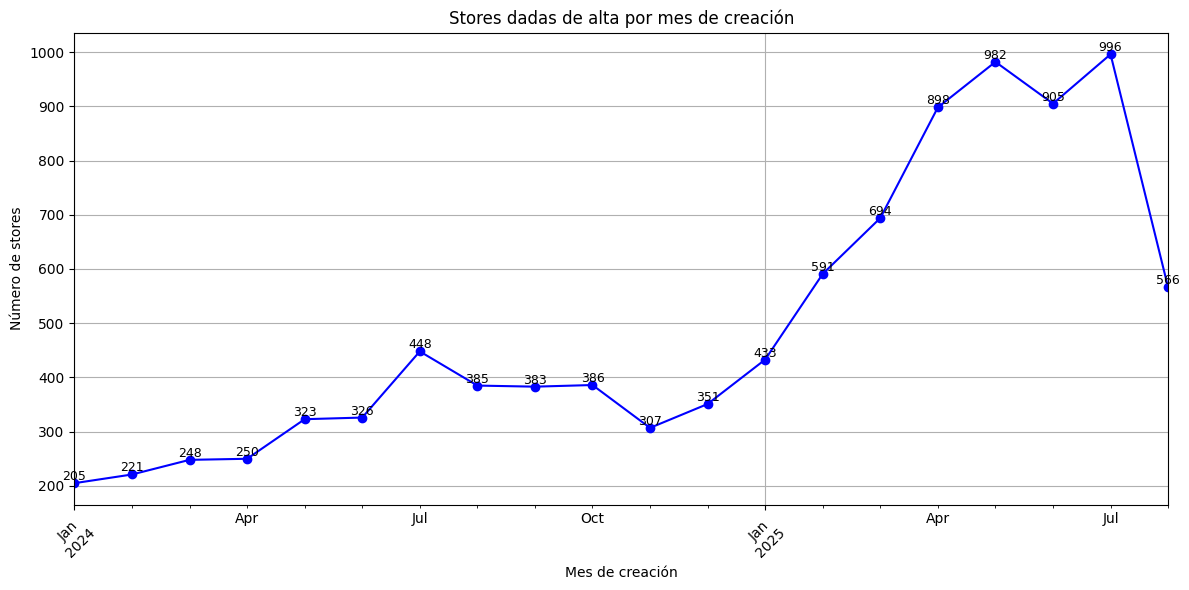

In [ ]:
# Grafico de stores dados de alta por mes de creación (gráfico de puntos que se contectan con linea y el punto tiene un label con el valor exacto)
creation_counts = df_stores[df_stores['created_date'] < '09-01-2025']['created_date'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(12, 6))
creation_counts.plot(kind='line', marker='o', color='blue')
for i, count in enumerate(creation_counts):
    plt.text(creation_counts.index[i].to_timestamp(), count, str(count), fontsize=9, ha='center', va='bottom')
plt.title('Stores dadas de alta por mes de creación')
plt.xlabel('Mes de creación')
plt.ylabel('Número de stores')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

relación entre antiguedad y churn (todos los churns nuestros)

#### Relación entre segmento y churn
- Evolucion temporal del churn por segmento

#### Relación entre categoria de comida y churn
- Evolucion temporal del churn por categoria de comida

#### Relación entre ubicación y churn
- Evolucion temporal del churn por ubicación

#### Relación entre conectividad y churn
- Análisis temporal y atemporal de la relación entre las variables de conectividad y churn